In [2]:
1

1

In [1]:
import torch # imported before PyQt
from PyQt6.QtWidgets import QApplication

# Data preparation

In [3]:
import json
import os
import urllib
def download_and_load_file(file_path, url):
  if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
      text_data = response.read().decode("utf-8")
    with open(file_path, "w", encoding="utf-8") as file:
      file.write(text_data)
  else:
    with open(file_path, "r", encoding="utf-8") as file:
      text_data = file.read()
  with open(file_path, "r") as file:
      data = json.load(file)
  return data
file_path = "instruction-data.json"
url = (
 "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
 "/main/ch07/01_main-chapter-code/instruction-data.json"
)
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [4]:
for i in range(4):
  print("Example entry:\n", data[1])

Example entry:
 {'instruction': 'Edit the following sentence for grammar.', 'input': 'He go to the park every day.', 'output': 'He goes to the park every day.'}
Example entry:
 {'instruction': 'Edit the following sentence for grammar.', 'input': 'He go to the park every day.', 'output': 'He goes to the park every day.'}
Example entry:
 {'instruction': 'Edit the following sentence for grammar.', 'input': 'He go to the park every day.', 'output': 'He goes to the park every day.'}
Example entry:
 {'instruction': 'Edit the following sentence for grammar.', 'input': 'He go to the park every day.', 'output': 'He goes to the park every day.'}


In [9]:
# Implementing the prompt formatting function
def format_input(entry):
  instruction_text = (
  f"Below is an instruction that describes a task. "
  f"Write a response that appropriately completes the request."
  f"\n\n### Instruction:\n{entry['instruction']}"
  )

  input_text = (
  f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
  )
  return instruction_text + input_text

In [ ]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

In [30]:
#partation the data
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion
train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


In [31]:
#Organizing data into training batches
import torch
from torch.utils.data import Dataset
class InstructionDataset(Dataset):

  def __init__(self, data, tokenizer):
    self.data = data
    self.encoded_texts = []
    for entry in data:
      instruction_plus_input = format_input(entry)
      response_text = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction_plus_input + response_text
      self.encoded_texts.append(
      tokenizer.encode(full_text)
      )
      
  def __getitem__(self, index):
    return self.encoded_texts[index]
  def __len__(self):
    return len(self.data)

In [32]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [11]:
#here just padd the sentence if lenght is less then max len  
def custom_collate_fn( batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device="cpu"):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst, targets_lst = [], []
  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]

    padded = (
    new_item + [pad_token_id] *(batch_max_length - len(new_item)))
    inputs = torch.tensor(padded[:-1])
    targets = torch.tensor(padded[1:])
    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index # fill to -100
    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
    targets = targets[:allowed_max_length]
    inputs_lst.append(inputs)
    targets_lst.append(targets)
  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)
  return inputs_tensor, targets_tensor

In [34]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
 inputs_1,
 inputs_2,
 inputs_3
)
device=torch.device("cuda") if torch.cuda.is_available() else "cpu"
input,output=(custom_collate_fn(batch))
print(input)
print(output)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


### why replace with -100 because in pythorch loss function -100 treated as ignore so if calculate with it it will not increase or decrease the loss

In [38]:
#example of -100 added  in loss
#1.Losses without  -100
logits_1 = torch.tensor(
 [[-1.0, 1.0],
 [-0.5, 1.5]]
)
targets_1 = torch.tensor([0, 1]) # Correct token indices to generate
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(f"Losses without -100 is  ",loss_1)


#Losses with -100
logits_2 = torch.tensor(
 [[-1.0, 1.0],
 [-0.5, 1.5],
 [-0.5, 1.5]]
)
targets_2 = torch.tensor([0, 1, -100])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(f"Losses with -100 is  ",loss_2)

Losses without -100 is   tensor(1.1269)
Losses with -100 is   tensor(1.1269)


In [12]:
from functools import partial
customized_collate_fn = partial(
 custom_collate_fn,
 device=device,
 allowed_max_length=1024
)

In [45]:
from torch.utils.data import DataLoader
num_workers = 0
batch_size = 8
torch.manual_seed(123)
train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
              train_dataset,
              batch_size=batch_size,
              collate_fn=customized_collate_fn,
              shuffle=True,
              drop_last=True,
              num_workers=num_workers
              )
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
              val_dataset,
              batch_size=batch_size,
              collate_fn=customized_collate_fn,
              shuffle=False,
              drop_last=False,
              num_workers=num_workers
              )
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            collate_fn=customized_collate_fn,
            shuffle=False,
            drop_last=False,
            num_workers=num_workers
            )

In [46]:
print("Train loader:")
for inputs, targets in train_loader:
 print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

In [11]:
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")

# Fine Tuning Part Started

# Generate next word

In [2]:
from GPT_Model import *
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,       # set to 0 for inference
    "qkv_bias": True        # GPT-2 uses bias
}

In [3]:
from safetensors.torch import load_file
import json

# Load the weights
weights = load_file(r"D:\Projects\IMPOLS\pretrained_models\gpt2\model.safetensors")
#load config
with open(r"D:\Projects\IMPOLS\pretrained_models\gpt2\config.json") as f:
    hf_config = json.load(f)


def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch → Left: {left.shape}, Right: {right.shape}")
    return nn.Parameter(right.clone().detach().float())

def load_hf_into_my_gpt(model, w):
    model.token_emb.weight = assign(model.token_emb.weight, w["wte.weight"])
    model.pos_emb.weight   = assign(model.pos_emb.weight,   w["wpe.weight"])

    for b in range(cfg["n_layer"]):
        p  = f"h.{b}"
        tb = model.tranformer_block[b]

        # LayerNorms
        tb.layernorm1.scale = assign(tb.layernorm1.scale, w[f"{p}.ln_1.weight"])
        tb.layernorm1.shift = assign(tb.layernorm1.shift, w[f"{p}.ln_1.bias"])
        tb.layernorm2.scale = assign(tb.layernorm2.scale, w[f"{p}.ln_2.weight"])
        tb.layernorm2.shift = assign(tb.layernorm2.shift, w[f"{p}.ln_2.bias"])

        # Q, K, V (split from concatenated HuggingFace format)
        qkv_w = w[f"{p}.attn.c_attn.weight"]  # [768, 2304]
        qkv_b = w[f"{p}.attn.c_attn.bias"]    # [2304]
        q_w, k_w, v_w = torch.split(qkv_w, 768, dim=1)
        q_b, k_b, v_b = torch.split(qkv_b, 768, dim=0)

        tb.mutihead_atten.w_query.weight = assign(tb.mutihead_atten.w_query.weight, q_w.T)
        tb.mutihead_atten.w_key.weight   = assign(tb.mutihead_atten.w_key.weight,   k_w.T)
        tb.mutihead_atten.w_value.weight = assign(tb.mutihead_atten.w_value.weight, v_w.T)
        tb.mutihead_atten.w_query.bias   = assign(tb.mutihead_atten.w_query.bias,   q_b)
        tb.mutihead_atten.w_key.bias     = assign(tb.mutihead_atten.w_key.bias,     k_b)
        tb.mutihead_atten.w_value.bias   = assign(tb.mutihead_atten.w_value.bias,   v_b)

        # Attention output projection
        tb.mutihead_atten.out_proj.weight = assign(
            tb.mutihead_atten.out_proj.weight, w[f"{p}.attn.c_proj.weight"].T)
        tb.mutihead_atten.out_proj.bias   = assign(
            tb.mutihead_atten.out_proj.bias,   w[f"{p}.attn.c_proj.bias"])

        # FeedForward
        tb.feed_forward.layer[0].weight = assign(
            tb.feed_forward.layer[0].weight, w[f"{p}.mlp.c_fc.weight"].T)
        tb.feed_forward.layer[0].bias   = assign(
            tb.feed_forward.layer[0].bias,   w[f"{p}.mlp.c_fc.bias"])
        tb.feed_forward.layer[2].weight = assign(
            tb.feed_forward.layer[2].weight, w[f"{p}.mlp.c_proj.weight"].T)
        tb.feed_forward.layer[2].bias   = assign(
            tb.feed_forward.layer[2].bias,   w[f"{p}.mlp.c_proj.bias"])

    # Final LayerNorm
    model.final_norm.scale = assign(model.final_norm.scale, w["ln_f.weight"])
    model.final_norm.shift = assign(model.final_norm.shift, w["ln_f.bias"])

    # Output head (weight tying)
    model.out_head.weight  = assign(model.out_head.weight,  w["wte.weight"])

    print("✅ Weights loaded successfully!")

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpt_model = GPT(cfg)        # must recreate after fixing cfg!
gpt_model.eval()

load_hf_into_my_gpt(gpt_model, weights)
gpt_model.to(device)

✅ Weights loaded successfully!


GPT(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (tranformer_block): Sequential(
    (0): Transfomers(
      (layernorm1): LayerNorm()
      (layernorm2): LayerNorm()
      (mutihead_atten): MultiHeadAttention(
        (w_query): Linear(in_features=768, out_features=768, bias=True)
        (w_key): Linear(in_features=768, out_features=768, bias=True)
        (w_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (feed_forward): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): Transfomers(
      (layernorm1): LayerNorm()
      (layernorm2): Laye

In [50]:
def predict(gpt_model=gpt_model,prompt="",next_new_token=5,temp=.7,topk=4):
  #temp+topk implemention to find next token generation
  tokenid=generate_text(
    model=gpt_model,
    ip_token_id = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device),
    max_new_tokens=next_new_token,
    context_size=int(cfg["context_len"]/4),
    temp=temp,
    topk=topk
  )
  return (token_id_to_text(tokenid,tokenizer))
prompt="My name is Trump what is your name"
predict(prompt=prompt,next_new_token=40,temp=.3,topk=3)  

["My name is Trump what is your name? I'm not a politician. I'm not a politician. I'm not a politician. I'm not a politician. I'm not a politician. I'm not a politician. I'm not"]

# Fine Tuning

In [77]:
#calculating the classification accuracy
def calc_accuracy_loader(dataloader, model, device, num_batches=None):
    model.eval()
    correct_prediction, num_examples = 0, 0

    with torch.no_grad():
        for i, (input_batch, target_batch) in enumerate(dataloader):
            if num_batches is not None and i >= num_batches:
                break

            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)

            logits = model(input_batch)                        # (batch, seq_len, vocab_size)
            predicted_labels = torch.argmax(logits, dim=-1)   # (batch, seq_len)

            # Only evaluate at positions where target != -100 (i.e., not padding)
            mask = target_batch != -100
            correct_prediction += (predicted_labels[mask] == target_batch[mask]).sum().item()
            num_examples += mask.sum().item()

    return correct_prediction / num_examples

In [78]:
import torch
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
gpt_model.to(device)
torch.manual_seed(123)
train_acc=calc_accuracy_loader(train_loader,gpt_model,device,num_batches=10)
val_acc=calc_accuracy_loader(val_loader,gpt_model,device,num_batches=10)
test_acc=calc_accuracy_loader(test_loader,gpt_model,device,num_batches=10)

print("Training Accuracy: ", train_acc)
print("Test Accuracy: ", test_acc)
print("Val Accuracy: ", val_acc)

cuda
Training Accuracy:  0.39116789957408654
Test Accuracy:  0.37836021505376344
Val Accuracy:  0.3854300385109114


In [79]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)                    # (batch, seq_len, vocab_size)

    # Flatten seq dimension for cross_entropy, and ignore -100 padding tokens
    loss = torch.nn.functional.cross_entropy(
        logits.view(-1, logits.size(-1)),          # (batch*seq_len, vocab_size)
        target_batch.view(-1),                     # (batch*seq_len,)
        ignore_index=-100
    )
    return loss

In [81]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i<num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss+=loss.item()
            
        else:
            break
    
    return total_loss/num_batches

In [82]:
gpt_model.to(device)
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(
    train_loader, gpt_model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
    val_loader, gpt_model, device, num_batches=5
    )
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 4.168718051910401
Validation loss: 4.0523687362670895


# finetune model

In [83]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    trainloss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
    trainloss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
  model.train()
  return trainloss,trainloss  

In [64]:
from tqdm import tqdm

In [ ]:
def train_instruction_finetune_simple(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,eval_iter,verbose=False):
  train_losses,val_losses,train_accs,val_accs=[],[],[],[]
  example_seen,global_step=0,-1
  epoch_iter=(range(num_epochs) if verbose else tqdm(range(num_epochs),desc="Training Epochs",leave=True)) #for progress bar tqdm uses
  for epoch in epoch_iter:
    if verbose:
      print("######################################")
      model.train()
      for input_batch,target_batch in train_loader:
        optimizer.zero_grad()
        loss=calc_loss_batch(input_batch,target_batch,model,device)
        loss.backward()
        optimizer.step()
        
        example_seen+=input_batch.shape[0]
        global_step += 1
        if global_step%eval_freq==0:
          train_loss,valloss=evaluate_model(model,train_loader,val_loader,device,eval_iter)
          train_losses.append(train_loss)
          val_losses.append(valloss)
          # if verbose:
          print(
                    f"Epoch: {epoch + 1} (Step: {global_step:06d}): "
                    f"TRAIN-LOSS={train_loss:.3f}, VAL-LOSS:{valloss:.3f}"
                  )
          train_acc=calc_accuracy_loader(train_loader,model,device=device,num_batches=eval_iter)  
          val_acc=calc_accuracy_loader(val_loader,model,device=device,num_batches=eval_iter)        
          # if verbose:
          print(f"Training Accuracy: {train_acc * 100:.2f}% | ", end="")
          print(f"Validation Accuracy: {val_acc * 100:.2f}%")
          train_accs.append(train_acc)
          val_accs.append(val_acc)
  return train_losses,val_losses,train_accs,val_accs,  example_seen      

In [85]:
import time
start_time=time.time()
torch.manual_seed(123)
optimizer=torch.optim.AdamW(gpt_model.parameters(),lr=5e-5,weight_decay=1e-3)
epochs=5
eval_freq=50
eval_iter=5#batch size
verbose=True
train_losses,val_losses,train_accs,val_accs,  example_seen =train_instruction_finetune_simple(
  gpt_model,
   train_loader=train_loader, 
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=epochs,
    eval_freq=eval_freq,
    eval_iter=eval_iter,
    verbose=verbose
)
end_time=time.time()
print(f"Training Complete in {(end_time-start_time)/60} min")

######################################
Epoch: 1 (Step: 000000): TRAIN-LOSS=3.240, VAL-LOSS:3.240
Training Accuracy: 41.70% | Validation Accuracy: 42.17%
Epoch: 1 (Step: 000050): TRAIN-LOSS=0.835, VAL-LOSS:0.835
Training Accuracy: 83.41% | Validation Accuracy: 81.17%
Epoch: 1 (Step: 000100): TRAIN-LOSS=0.645, VAL-LOSS:0.645
Training Accuracy: 85.55% | Validation Accuracy: 83.30%
######################################
Epoch: 2 (Step: 000150): TRAIN-LOSS=0.602, VAL-LOSS:0.602
Training Accuracy: 87.28% | Validation Accuracy: 83.69%
Epoch: 2 (Step: 000200): TRAIN-LOSS=0.513, VAL-LOSS:0.513
Training Accuracy: 86.82% | Validation Accuracy: 83.60%
######################################
Epoch: 3 (Step: 000250): TRAIN-LOSS=0.410, VAL-LOSS:0.410
Training Accuracy: 87.83% | Validation Accuracy: 84.12%
Epoch: 3 (Step: 000300): TRAIN-LOSS=0.408, VAL-LOSS:0.408
Training Accuracy: 89.21% | Validation Accuracy: 84.30%
######################################
Epoch: 4 (Step: 000350): TRAIN-LOSS=0.346, VAL

In [86]:
#save the mode after classification fine tune
torch.save(gpt_model.state_dict(), "Instruction_fine_tune.pth")

In [87]:
import matplotlib.pyplot as plt

def plotvalues(epochs_seen, examples_seen, train_values, val_values, label="loss"):
        fig, ax1 = plt.subplots(figsize=(5, 3))
        
        ax1.plot(epochs_seen, train_losses, label=f"Training {label}")
        ax1.plot(epochs_seen, val_losses, linestyle="-.", label=f"Validation {label}")
        ax1.set_xlabel("Epochs")
        ax1.set_ylabel(label.capitalize())
        ax1.legend(loc="upper right")
        
        ax2 = ax1.twiny()
        ax2.plot(examples_seen, train_values, alpha=0)
        ax2.set_xlabel("Examples seen")
        
        fig.tight_layout()
        plt.show()

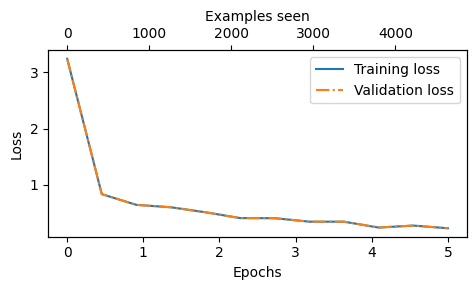

In [88]:
epochs_tensor=torch.linspace(0,epochs,len(train_losses))
example_seen_tensor=torch.linspace(0,example_seen,len(train_losses))
plotvalues(epochs_tensor,example_seen_tensor,train_losses,val_losses)

In [89]:
with torch.no_grad():
    train_acc = calc_accuracy_loader(train_loader, gpt_model, device, num_batches=10)
    val_acc = calc_accuracy_loader(val_loader, gpt_model, device, num_batches=10)
    test_acc = calc_accuracy_loader(test_loader, gpt_model, device, num_batches=10)

print("Training Accuracy: ", train_acc)
print("Test Accuracy: ", test_acc)
print("Val Accuracy: ", val_acc)

Training Accuracy:  0.9421018134149006
Test Accuracy:  0.8449820788530465
Val Accuracy:  0.8562259306803595


# Testing on Unseen Data

In [5]:
def generate_response(
    entry,           # dict with 'instruction' and optional 'input' keys
    model,
    tokenizer,
    device,
    max_new_tokens=256,
    temp=0.0,        # 0 = greedy (deterministic), >0 = sampling
    topk=None
):
    model.eval()

    # Format input exactly as it was done during training
    prompt = format_input(entry)
    prompt += "\n\n### Response:\n"   # signal model to start responding

    # Encode prompt
    input_ids = tokenizer.encode(prompt)
    input_tensor = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)

    # Generate tokens
    with torch.no_grad():
        output_ids = generate_text(
            model=model,
            ip_token_id=input_tensor,
            max_new_tokens=max_new_tokens,
            context_size=cfg["context_len"],
            temp=temp,
            topk=topk
        )

    # Decode only the newly generated tokens (skip the prompt)
    generated_ids = output_ids[0][len(input_ids):]
    response = tokenizer.decode(generated_ids.tolist())

    # Stop at <|endoftext|> if model generated it
    if "<|endoftext|>" in response:
        response = response.split("<|endoftext|>")[0]

    return response.strip()

In [95]:
entry = {
    "instruction": "Edit the following sentence for grammar.",
    "input": "He go to the park every day."
}

response = generate_response(
    entry=entry,
    model=gpt_model,
    tokenizer=tokenizer,
    device=device,
    max_new_tokens=100,
    temp=0.0       # greedy — best for factual/instruction tasks
)
print(response)
# → "He goes to the park every day."


# For entries with no input field:
entry2 = {
    "instruction": "List three benefits of exercise.",
    "input": ""
}
print(generate_response(entry2, gpt_model, tokenizer, device))

He goes to the park every day.
1. Works well for those under 30.

2. Improves coordination and decision making.
3. Helps you complete your assignment.


In [3]:
import torch
import tiktoken
from GPT_Model import *   # your GPT class, generate_text, token_id_to_text, format_input

# ── 1. Config (must match exactly what you used during training) ──────────────


cfg=GPT_2_config={
  "vocab":50257,
  "context_len":1024,
  "emb_dim":768,
  "n_head":12,
  "n_layer":12,
  "dropout":0.1,
  "qkv_bias":True  
}


# ── 2. Load tokenizer ─────────────────────────────────────────────────────────
tokenizer = tiktoken.get_encoding("gpt2")

# ── 3. Rebuild model skeleton + load saved weights ───────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpt_model = GPT(cfg)
gpt_model.load_state_dict(
    torch.load("Instruction_fine_tune.pth", map_location=device)
)
gpt_model.to(device)
gpt_model.eval()   # disables dropout — important for inference!
print("Model loaded successfully!")

# ── 4. Inference function ─────────────────────────────────────────────────────

# Implementing the prompt formatting function
def format_input(entry):
    instruction_text = (
    f"Below is an instruction that describes a task. "
    f"Write a response that appropriately completes the request."
    f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = (
    f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    return instruction_text + input_text

def generate_response(entry, model, tokenizer, device,
                       max_new_tokens=256, temp=0.0, topk=None):

    # Format exactly like training data
    prompt = format_input(entry)
    prompt += "\n\n### Response:\n"

    # Encode → tensor
    input_ids    = tokenizer.encode(prompt)
    input_tensor = torch.tensor(input_ids).unsqueeze(0).to(device)

    # Generate
    with torch.no_grad():
        output_ids = generate_text(
            model          = model,
            ip_token_id    = input_tensor,
            max_new_tokens = max_new_tokens,
            context_size   = cfg["context_len"],
            temp           = temp,
            topk           = topk
        )

    # Decode only the new tokens (skip the prompt part)
    generated_ids = output_ids[0][len(input_ids):]
    response      = tokenizer.decode(generated_ids.tolist())

    # Cut off at end-of-text token if model generated it
    if "<|endoftext|>" in response:
        response = response.split("<|endoftext|>")[0]

    return response.strip()


# ── 5. Run inference ──────────────────────────────────────────────────────────
entry = {
    "instruction": "Edit the following sentence for grammar.",
    "input":       "My name are "
}

response = generate_response(
    entry          = entry,
    model          = gpt_model,
    tokenizer      = tokenizer,
    device         = device,
    max_new_tokens = 100,
    temp           = 1    # greedy decoding — best for instruction tasks
)

print("Response:", response)

Model loaded successfully!
Response: My name are Lawrence.


In [4]:
entry = {
    "instruction": "add two number.",
    "input":       "first number is 4 and second number is 34"
}

response = generate_response(
    entry          = entry,
    model          = gpt_model,
    tokenizer      = tokenizer,
    device         = device,
    max_new_tokens = 10,
    temp           = 1   # greedy decoding — best for instruction tasks
)

print("Response:", response)

Response: 2nd number is 3 and so on.


In [7]:
import torch
import tiktoken
from GPT_Model import * 


cfg=GPT_2_config={
  "vocab":50257,
  "context_len":1024,
  "emb_dim":768,
  "n_head":12,
  "n_layer":12,
  "dropout":0.1,
  "qkv_bias":True  
}


# ── 2. Load tokenizer ─────────────────────────────────────────────────────────
tokenizer = tiktoken.get_encoding("gpt2")


class InstructionGPT:

    def __init__(self, cfg, path):
        self.cfg       = cfg
        self.device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = tiktoken.get_encoding("gpt2")
        self.model     = self._load(path)

    def _load(self, path):
        model = GPT(self.cfg)
        model.load_state_dict(torch.load(path, map_location=self.device))
        model.to(self.device)
        model.eval()
        print("Model loaded successfully!")
        return model

    def _format_input(self, entry):
        instruction_text = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request."
            f"\n\n### Instruction:\n{entry['instruction']}"
        )
        input_text = (
            f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
        )
        return instruction_text + input_text

    def generate(self, entry, max_new_tokens=256, temp=0.0, topk=None):
        prompt       = self._format_input(entry) + "\n\n### Response:\n"
        input_ids    = self.tokenizer.encode(prompt)
        input_tensor = torch.tensor(input_ids).unsqueeze(0).to(self.device)

        with torch.no_grad():
            output_ids = generate_text(
                model          = self.model,
                ip_token_id    = input_tensor,
                max_new_tokens = max_new_tokens,
                context_size   = self.cfg["context_len"],
                temp           = temp,
                topk           = topk
            )

        generated_ids = output_ids[0][len(input_ids):]
        response      = self.tokenizer.decode(generated_ids.tolist())

        if "<|endoftext|>" in response:
            response = response.split("<|endoftext|>")[0]

        return response.strip()


In [8]:
gpt = InstructionGPT(cfg, path="Instruction_fine_tune.pth")
# Inference as many times as you want
entry = {
    "instruction": "Edit the following sentence for grammar.",
    "input": "He  to the park every day."
}
print(gpt.generate(entry))

He goes to the park every day.


In [13]:

def inference():
    i = 0
    # ✅ Fix 1: was "while(exit)" — exit is a built-in function, always True-ish
    # should be "while True" to keep the loop running
    while True:
        if i == 0:
            gpt = InstructionGPT(cfg, path="Instruction_fine_tune.pth")
            i += 1
        else:
            text = input("Enter the text (or type 'exit' to quit): ")

            if text.lower() == "exit":
                print("Program Exited")
                break
            else:
                # ✅ Fix 2: was gpt.generate(entry) — entry was never defined
                # build the entry dict from the user's input text
                entry = {
                    "instruction": text,
                    "input": ""       # no extra input for simple chat
                }
                response = gpt.generate(entry)
                print(f"\nResponse: {response}\n")


if __name__ == "__main__":

  cfg=GPT_2_config={
    "vocab":50257,
    "context_len":1024,
    "emb_dim":768,
    "n_head":12,
    "n_layer":12,
    "dropout":0.1,
    "qkv_bias":True  
  }


  # ── 2. Load tokenizer ─────────────────────────────────────────────────────────
  tokenizer = tiktoken.get_encoding("gpt2")


  inference()

Model loaded successfully!

Response: my name turmp is a Polish mobile phone company.


Response: Where is the nearest hospital?


Response: You are a fucking fucking fuckton of a man.

Program Exited


# Evalute the mode there are 3 method
1.By Human(qualatative)\
2.MMLU\
3.Using other model to evalute(quantative)